# Fast MRI cartesian GRE sequence artifacts

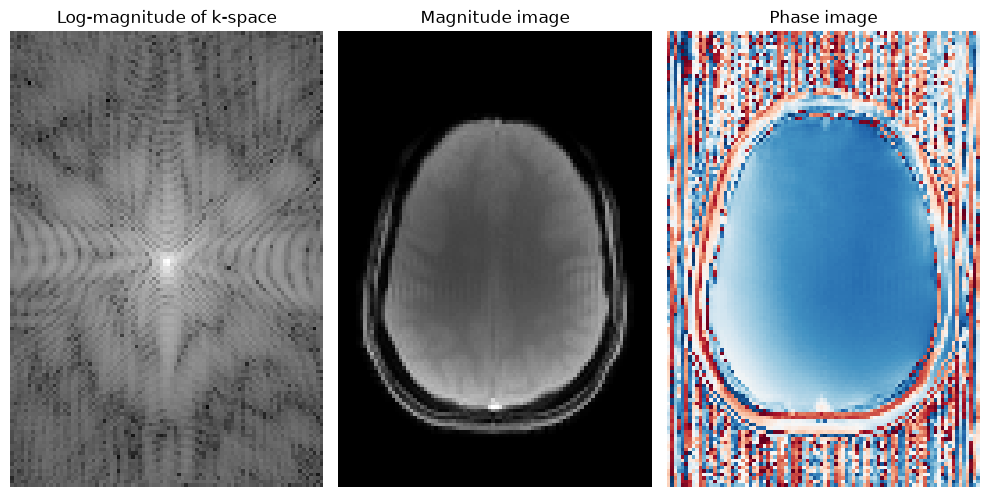

In [11]:
#| label: figkspace_image
# Reference plot

import numpy as np
import matplotlib.pyplot as plt

kspace = np.load("../data/kspace_combined.npy")

# Magnitude of k-space
kspace_mag = np.abs(kspace)

# Log-magnitude of k-space
kspace_log_mag = np.log(kspace_mag)

# Image space
image = np.fft.ifftshift( np.fft.ifft2( np.fft.fftshift(kspace)))

# Magnitude and phase
image_mag = np.abs(image)
image_phase = np.angle(image)

# Display the results
fig, axes = plt.subplots(1, 3, figsize=(10, 10))

axes[0].imshow(kspace_log_mag, cmap="gray")
axes[0].set_title("Log-magnitude of k-space")
axes[0].axis("off")

axes[1].imshow(image_mag, cmap="gray")
axes[1].set_title("Magnitude image")
axes[1].axis("off")

axes[2].imshow(image_phase, cmap="RdBu_r")
axes[2].set_title("Phase image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

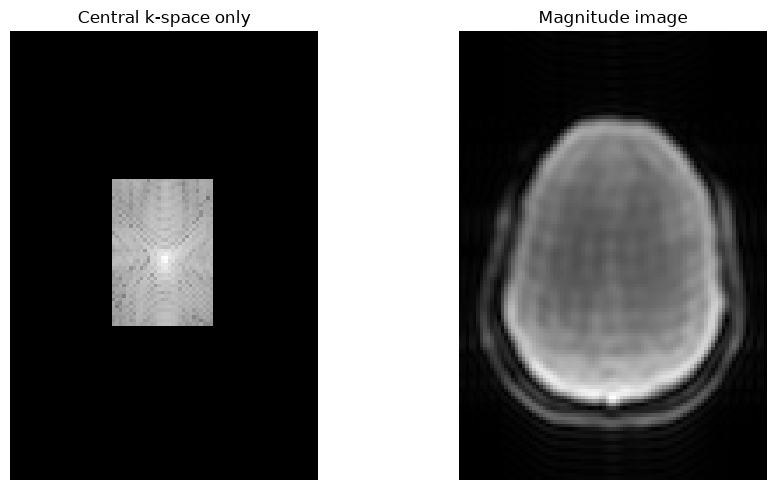

In [12]:
#| label: figKeep_kspace_center
# Keep only the center of kspace

ny, nx = kspace.shape

# Define central region
x_start = 2*(nx - nx // 2) // 3
x_end   = x_start + nx // 3

y_start = 2*(ny - ny // 2) // 3
y_end   = y_start + ny // 3

# Mask: False everywhere, True only in the center
mask = np.zeros((ny, nx), dtype=bool)
mask[y_start:y_end, x_start:x_end] = True

# Keep only the center of k-space
kspace_masked = kspace * mask

# Log magnitude for visualization
log_kspace_masked = np.log(np.abs(kspace_masked) + 1e-8)

# Reconstruct image
image_masked = np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(kspace_masked)))

image_masked_mag = np.abs(image_masked)

# Display the results
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(log_kspace_masked, cmap="gray")
ax[0].set_title("Central k-space only")
ax[0].axis("off")

ax[1].imshow(image_masked_mag, cmap="gray")
ax[1].set_title("Magnitude image")
ax[1].axis("off")

plt.tight_layout()
plt.show()

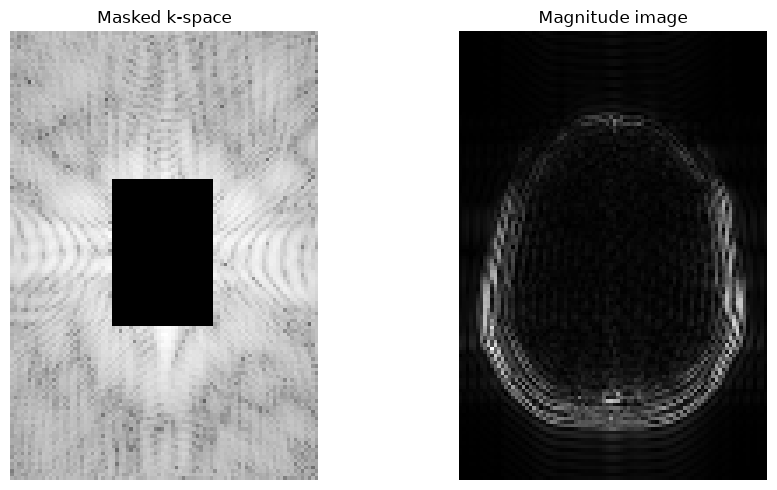

In [13]:
#| label: figMask_kspace_center
# Mask the center of kspace

ny, nx = kspace.shape

# Mask = True everywhere
mask = np.ones((ny, nx), dtype=bool)

# Define central region to remove
x_start = 2*(nx - nx // 2) // 3
x_end   = x_start + nx // 3

y_start = 2*(ny - ny // 2) // 3
y_end   = y_start + ny // 3

# Set the center of k-space to zero
mask[y_start:y_end, x_start:x_end] = False

# Apply mask
kspace_masked = kspace * mask

# Log magnitude for visualization
log_kspace_masked = np.log(np.abs(kspace_masked) + 1e-8)

# Reconstruct image
image_masked = np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(kspace_masked)))

image_masked_mag = np.abs(image_masked)

# Display the results
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(log_kspace_masked, cmap="gray")
ax[0].set_title("Masked k-space")
ax[0].axis("off")

ax[1].imshow(image_masked_mag, cmap="gray")
ax[1].set_title("Magnitude image")
ax[1].axis("off")

plt.tight_layout()
plt.show()

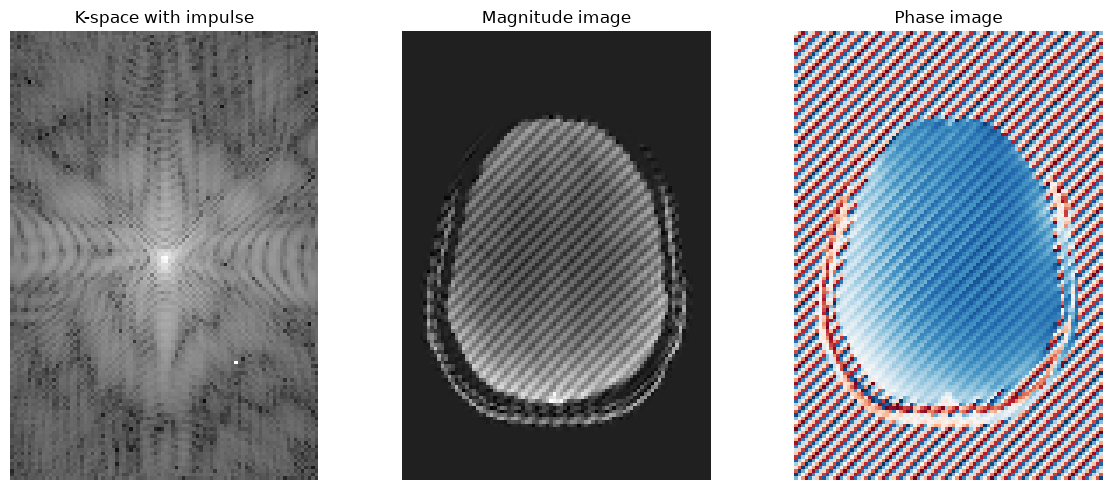

In [14]:
#| label: figKspaceImpulse
# Add an inpulse in kspace

import numpy as np
import matplotlib.pyplot as plt

# Load k-space
kspace = np.load("../data/kspace_combined.npy")


# Add an impulse in k-space
def p_addition(k, A_frac=0.10, k0=(30, 20)):
    k2 = k.copy()

    ny, nx = k.shape

    # Amplitude of the impulse
    A = A_frac * np.abs(k).max()

    # Position of the impulse relative to k-space center
    y = ny // 2 + k0[0]
    x = nx // 2 + k0[1]

    k2[y, x] += A

    return k2


kspace_impulse = p_addition(kspace, A_frac=1, k0=(30, 20))


# K-space visualization
kspace_mag = np.abs(kspace_impulse)

# Add epsilon to avoid log(0)
kspace_log_mag = np.log(kspace_mag + 1e-8)


# Image reconstruction
image_impulse = np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(kspace_impulse)))

# Magnitude and phase
image_impulse_mag = np.abs(image_impulse)
image_impulse_phase = np.angle(image_impulse)

# Display the results
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].imshow(kspace_log_mag, cmap="gray")
axes[0].set_title("K-space with impulse")
axes[0].axis("off")

axes[1].imshow(image_impulse_mag, cmap="gray")
axes[1].set_title("Magnitude image")
axes[1].axis("off")

axes[2].imshow(image_impulse_phase, cmap="RdBu_r")
axes[2].set_title("Phase image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

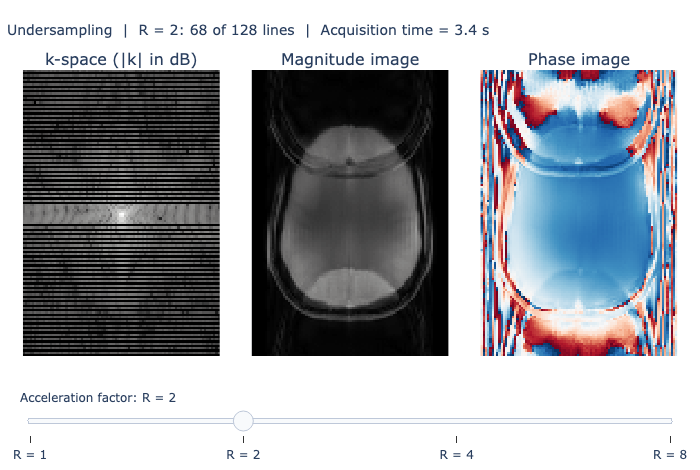

In [ ]:
#| label: figUndersampling
# Undersampling of the real k-space: one line in R + fully sampled centre (ACS), zero-filled
kspace = np.load("../data/kspace_combined.npy")
ny, nx = kspace.shape
TR = 0.05                                     # s, one ky line per TR
N_ACS = max(8, ny // 16)                      # central lines always acquired (ACS)
Rs, DEFAULT = [1, 2, 4, 8], 1                 # slider values, index shown first

def k2i(k):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k)))

def sampling_lines(R=1):
    """Keep one ky line in R, plus the ACS block at the centre."""
    if R == 1:
        return np.arange(ny)
    regular = np.arange((ny // 2) % R, ny, R)
    center = np.arange(ny // 2 - N_ACS // 2, ny // 2 + N_ACS // 2)
    return np.union1d(regular, center)

# Fixed display windows, so all R are shown on the same scale
kabs_max = np.abs(kspace).max()
vmax = np.abs(k2i(kspace)).max()
K_DB_MIN = max(-127, int(np.floor(20 * np.log10(np.abs(kspace)[np.abs(kspace) > 0].min() / kabs_max))))

def kspace_db(k):
    with np.errstate(divide="ignore"):
        db = 20 * np.log10(np.abs(k) / kabs_max)
    return np.clip(np.nan_to_num(db, neginf=-128), -128, 0).round().astype(np.int8)

# Light web page: images shown at <= 128 px; k-space keeps every ky line so skipped lines stay visible
step = max(1, int(np.ceil(max(ny, nx) / 128)))
x_c, y_c = np.arange(0, nx, step), np.arange(0, ny, step)
kx_c, ky_c = np.arange(0, nx, step) - nx // 2, np.arange(ny) - ny // 2

titles = []
for i, R in enumerate(Rs):
    lines = sampling_lines(R)
    k = np.zeros_like(kspace)
    k[lines] = kspace[lines]                  # zero-filling: skipped lines stay at 0
    img = k2i(k)
    show = (i == DEFAULT)
    fig.add_trace(go.Heatmap(z=kspace_db(k)[:, ::step], x=kx_c, y=ky_c, colorscale="gray",
                             zmin=K_DB_MIN, zmax=0, showscale=False, visible=show,
                             hovertemplate="kx = %{x}, ky = %{y}<br>|k| = %{z} dB<extra></extra>"), 1, 1)
    fig.add_trace(go.Heatmap(z=np.round(100 * np.abs(img[::step, ::step]) / vmax).astype(np.uint8),
                             x=x_c, y=y_c, colorscale="gray", zmin=0, zmax=100, showscale=False,
                             visible=show,
                             hovertemplate="x = %{x}, y = %{y}<br>magnitude = %{z} % of max<extra></extra>"), 1, 2)
    fig.add_trace(go.Heatmap(z=np.round(np.degrees(np.angle(img[::step, ::step]))).astype(np.int16),
                             x=x_c, y=y_c, colorscale="RdBu_r", zmin=-180, zmax=180, showscale=False,
                             visible=show,
                             hovertemplate="x = %{x}, y = %{y}<br>phase = %{z}°<extra></extra>"), 1, 3)
    titles.append(f"Undersampling  |  R = {R}: {len(lines)} of {ny} lines  |  "
                  f"Acquisition time = {len(lines) * TR:.1f} s")

steps = []
for i, R in enumerate(Rs):
    vis = [False] * len(fig.data)
    vis[3 * i:3 * i + 3] = [True] * 3
    steps.append(dict(method="update", label=f"R = {R}",
                      args=[{"visible": vis}, {"title.text": titles[i]}]))

fig.update_xaxes(showticklabels=False, showgrid=False, constrain="domain")
for c, ax in zip([1, 2, 3], ["x", "x2", "x3"]):
    fig.update_yaxes(showticklabels=False, showgrid=False, autorange="reversed",
                     constrain="domain", scaleanchor=ax, row=1, col=c)
fig.update_layout(title=dict(text=titles[DEFAULT], font=dict(size=14), x=0.01),
                  sliders=[dict(active=DEFAULT, steps=steps, pad={"t": 30},
                                currentvalue={"prefix": "Acceleration factor: "})],
                  template="plotly_white", height=470, margin=dict(l=20, r=20, t=70, b=20))
fig